===== IRIS DATASET =====
Dataset Shape: (150, 6)

===== FIRST 10 ROWS =====
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
5   6            5.4           3.9            1.7           0.4  Iris-setosa
6   7            4.6           3.4            1.4           0.3  Iris-setosa
7   8            5.0           3.4            1.5           0.2  Iris-setosa
8   9            4.4           2.9            1.4           0.2  Iris-setosa
9  10            4.9           3.1            1.5           0.1  Iris-setosa

===== COLUMN NAMES =====
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengt

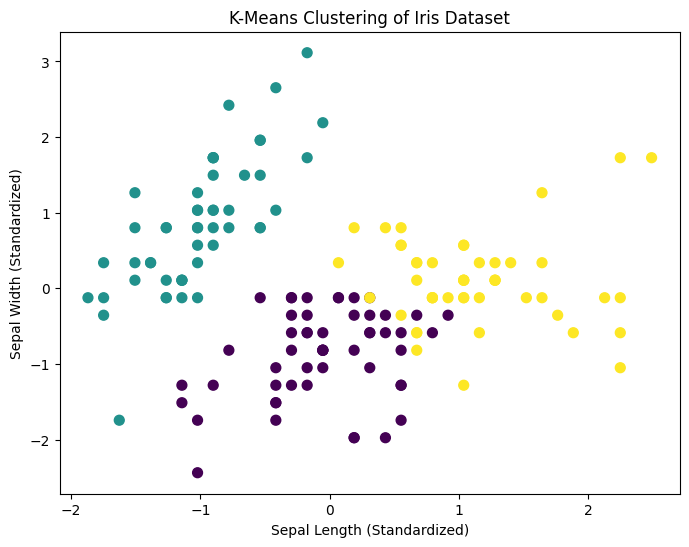


===== PCA =====
Original dimensions: (150, 4)
Reduced dimensions: (150, 2)

Explained Variance Ratio:
[0.72770452 0.23030523]

Total Variance Explained: 0.9580097536148199


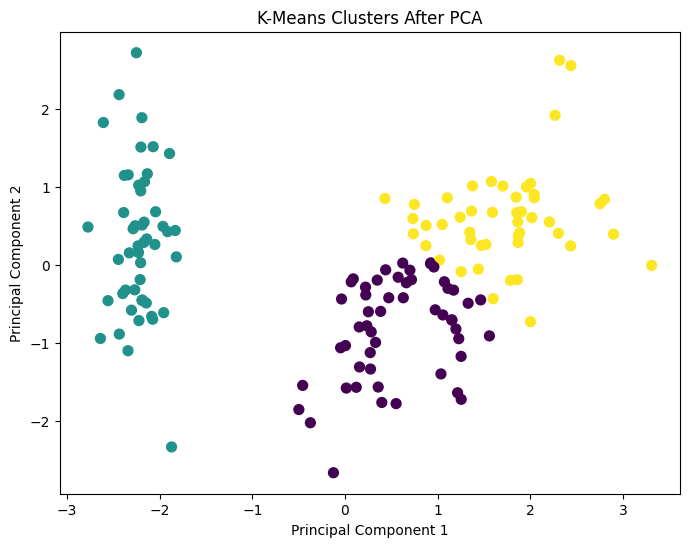


===== COMPLETE COMPARISON =====
       True Species  Predicted Cluster
0       Iris-setosa                  1
1       Iris-setosa                  1
2       Iris-setosa                  1
3       Iris-setosa                  1
4       Iris-setosa                  1
..              ...                ...
145  Iris-virginica                  2
146  Iris-virginica                  0
147  Iris-virginica                  2
148  Iris-virginica                  2
149  Iris-virginica                  0

[150 rows x 2 columns]

===== CLUSTERING PERFORMANCE =====
Adjusted Rand Index: 0.6201351808870379

===== CONFUSION MATRIX =====
[[ 0 50  0]
 [39  0 11]
 [14  0 36]]


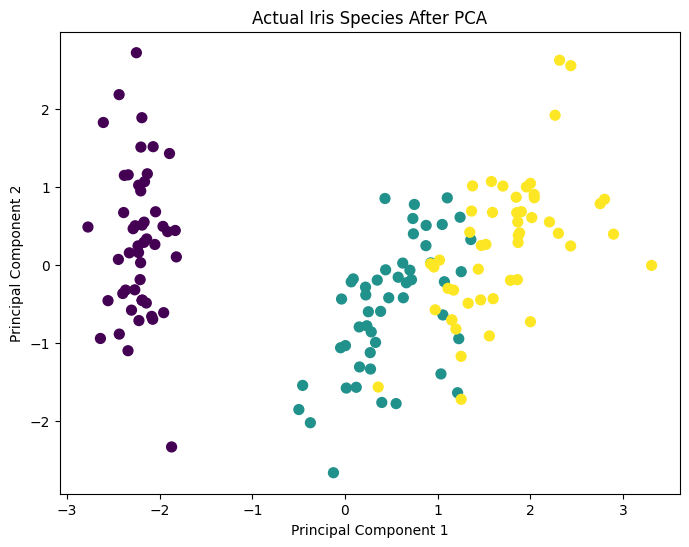



       IRIS FLOWER CLUSTERING PROJECT
Total samples: 150
Original features: 4
Number of clusters (K): 3
PCA components: 2
Adjusted Rand Index: 0.6201351808870379

Conclusion:
K-Means clustering was successfully applied to the Iris dataset.
The dataset was divided into 3 clusters.
PCA reduced the original 4 dimensions to 2 dimensions.
The clusters were visualized using scatter plots.
The predicted clusters were compared with the actual species labels.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, confusion_matrix

df = pd.read_csv("Iris.csv")

print("===== IRIS DATASET =====")
print("Dataset Shape:", df.shape)

print("\n===== FIRST 10 ROWS =====")
print(df.head(10))

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

X = df[features]

print("\n===== FEATURES USED =====")
print(features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n===== STANDARDIZATION =====")
print("Data standardized successfully.")

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Predicted_Cluster"] = clusters

print("\n===== K-MEANS CLUSTERING =====")
print("Number of clusters:", 3)

print("\nCluster counts:")
print(pd.Series(clusters).value_counts().sort_index())

comparison = df[["Species", "Predicted_Cluster"]]

print("\n===== TRUE LABEL VS PREDICTED CLUSTER =====")
print(comparison.head(20))

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    s=50
)

plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.title("K-Means Clustering of Iris Dataset")

plt.show()

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\n===== PCA =====")
print("Original dimensions:", X_scaled.shape)
print("Reduced dimensions:", X_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal Variance Explained:",
    pca.explained_variance_ratio_.sum()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters After PCA")

plt.show()

print("\n===== COMPLETE COMPARISON =====")

comparison = pd.DataFrame({
    "True Species": df["Species"],
    "Predicted Cluster": clusters
})

print(comparison)

true_labels = df["Species"].astype("category").cat.codes

ari = adjusted_rand_score(true_labels, clusters)

print("\n===== CLUSTERING PERFORMANCE =====")
print("Adjusted Rand Index:", ari)

cm = confusion_matrix(true_labels, clusters)

print("\n===== CONFUSION MATRIX =====")
print(cm)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=true_labels,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Actual Iris Species After PCA")

plt.show()

print("\n")
print("==============================================")
print("       IRIS FLOWER CLUSTERING PROJECT")
print("==============================================")

print("Total samples:", X.shape[0])
print("Original features:", X.shape[1])
print("Number of clusters (K):", 3)
print("PCA components:", 2)
print("Adjusted Rand Index:", ari)

print("\nConclusion:")
print("K-Means clustering was successfully applied to the Iris dataset.")
print("The dataset was divided into 3 clusters.")
print("PCA reduced the original 4 dimensions to 2 dimensions.")
print("The clusters were visualized using scatter plots.")
print("The predicted clusters were compared with the actual species labels.")